# Lubuskie — Actuarial Climate Index — wariant pięcioskładnikowy

Obliczenia regionalne na podstawie **177 punktów** z `data/poland/grid/lubuskie/grid.csv`.
Metoda odpowiada części lądowej `pomeranian_aci_workflow.ipynb`: najpierw średnie dzienne
z punktów, następnie wskaźniki ekstremów i standaryzacja osobno dla regionu.

**Okres:** 1961-01-01–2026-04-30. **Baza:** 1961–1991 włącznie.
**Indeks:** `(T90p - T10p + Rx5day + CDD + W90p) / 5`.
Poziom morza nie wchodzi do tego wariantu. Do porównania z pomorskim używaj `PomACI_land5`.

## Uruchomienie
1. Wybierz kernel Python z pakietami z `requirements-poland.txt` i uruchom notebook z katalogu projektu.
2. W konfiguracji ustaw `RUN_ARCO_DOWNLOAD = True`, następnie wybierz **Run All**.
3. Gdy pojawi się ukryte pole, wpisz token CDS. Token nie jest wpisywany do kodu ani zapisywany w wynikach.
4. Po pobraniu można ponownie ustawić flagę na `False`. Kompletne bloki dzienne są wykorzystywane ponownie.

Pobieranie obejmuje długą historię 177 punktów i może potrwać. Każdy ukończony rok jest zapisywany oddzielnie;
przerwanie nie wymaga ponownego pobierania ukończonych lat. Roczne dane godzinowe są zachowywane w NetCDF.
Bez kompletu danych notebook pokazuje stan przygotowania i nie generuje pozornych wyników indeksu.

Źródło: [ECMWF — dokumentacja ERA5-Land ARCO](https://confluence.ecmwf.int/spaces/CKB/pages/536218894).
Adresy trzech magazynów odpowiadają notebookowi pomorskiemu. Opad ARCO jest już rozłożony na wartości godzinowe;
przy sumowaniu dobowym stosujemy przesunięcie znacznika czasu o jedną godzinę, jak w dotychczasowym kodzie.

## Status metodologii
Ten notebook odtwarza **aktualną implementację mazowiecką**, a nie niezależnie zweryfikowany kod R autorów prezentacji. Nie zmieniamy wzorów podczas rozszerzenia na kolejne regiony.
- Kwantyle temperatury 10% i 90% są obliczane z próby w pięciodniowym oknie.
- Próg wiatru w bibliotece `iaci` wynosi średnia + kwantyl rozkładu normalnego × odchylenie standardowe; wymaga uzgodnienia z opisem na slajdzie 72.
- Standaryzacja temperatury używa średniej odchyleń TX i TN, co różni się od dosłownego odczytania slajdów 74–75.
- Pięć składników, bez poziomu morza: adaptacja dla regionów śródlądowych. Nie jest to sześcioskładnikowy PomACI.
- Braki danych zatrzymują obliczenia. Nie zastępujemy ich zerem ani nie wykluczamy automatycznie punktów.

**Uwaga:** dane dzienne są eksportowane do CSV po jednym pliku na punkt. Pliki `.nc` służą jako lokalne bloki robocze do wznawiania pobierania. Pobieraj województwa kolejno; nie uruchamiaj wszystkich notebooków jednocześnie.


In [2]:
from pathlib import Path
from getpass import getpass
import hashlib
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "python_iaci/iaci").is_dir():
    raise RuntimeError("Otwórz notebook z katalogiem roboczym C:/Climate_index.")
sys.path.insert(0, str(PROJECT_ROOT / "python_iaci"))
from iaci import (climate_input, tx90p, tx10p, tn90p, tn10p, rx5day, w90p,
                  t90p_std, t10p_std, rx5day_std, w90p_std,
                  calculate_standardized, merge_components)

REGION = "lubuskie"
GRID_FILE = PROJECT_ROOT / "data/poland/grid" / REGION / "grid.csv"
DATA_DIR = PROJECT_ROOT / "data/poland" / REGION
RAW_DIR = DATA_DIR / "arco_hourly"
DAILY_DIR = DATA_DIR / "daily_grid"
OUTPUT_DIR = PROJECT_ROOT / "output/poland" / REGION
START = pd.Timestamp("1961-01-01")
END = pd.Timestamp("2026-04-30")
BASE_RANGE = (1961, 1991)
TEMP_WINDOW_DAYS = 5
CLIMATE_COLUMNS = ["TMAX", "TMIN", "PRCP", "WP"]
RUN_ARCO_DOWNLOAD = True  # Zmień na True, aby pobrać dane.
PIPELINE_VERSION = "lubuskie-arco-daily-v1"
EXPECTED_DAYS = pd.date_range(START, END, freq="D")
EXPECTED_MONTHS = pd.period_range(START, END, freq="M").astype(str)
YEARS = range(START.year, END.year + 1)
print("Okres:", START.date(), "–", END.date(), "| Baza:", BASE_RANGE)
REGION_LABEL = 'Lubuskie'
NUTS_CODE = 'PL43'

# Wspólna konfiguracja map regionalnych.
REGION_LABEL = 'Lubuskie'
NUTS_CODES = ['PL43']
METRICS = ['T90p', 'T10p_oriented', 'Rx5day', 'CDD', 'W90p', 'ACI_land5']
LABELS = ['Wysokie temperatury — T90p', 'Niskie temperatury — −T10p', 'Opady — Rx5day', 'Susza — CDD', 'Wiatr — W90p', 'Indeks land5']


Okres: 1961-01-01 – 2026-04-30 | Baza: (1961, 1991)


## 1. Lista punktów województwa
Lista wejściowa jest źródłem przypisania punktów do województwa. Nie pobieramy ponownie granic ani nie
odrzucamy punktów na podstawie kształtu mapy. Brak danych zostanie rozpoznany dopiero po pobraniu całego okresu.

Punkty: 177


,grid_point_id,latitude,longitude,grid_resolution,voivodeship,nuts_id
0,ERA5_51.4_15.0,51.4,15.0,0.1° × 0.1°,Lubuskie,PL43
1,ERA5_51.5_14.9,51.5,14.9,0.1° × 0.1°,Lubuskie,PL43
2,ERA5_51.5_15.0,51.5,15.0,0.1° × 0.1°,Lubuskie,PL43
3,ERA5_51.5_15.1,51.5,15.1,0.1° × 0.1°,Lubuskie,PL43
4,ERA5_51.5_15.2,51.5,15.2,0.1° × 0.1°,Lubuskie,PL43


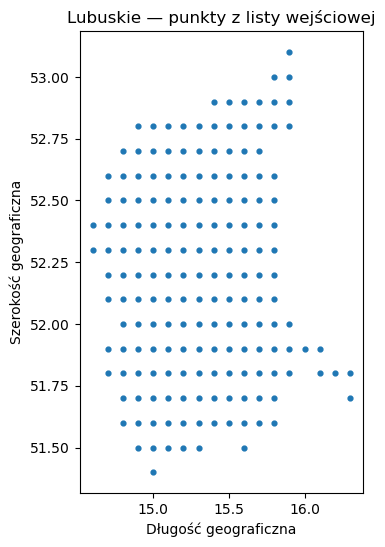

In [3]:
grid = pd.read_csv(GRID_FILE).sort_values(["latitude", "longitude"]).reset_index(drop=True)
if grid[["latitude", "longitude"]].isna().any().any():
    raise ValueError("Brak współrzędnych w siatce.")
if grid[["latitude", "longitude"]].duplicated().any():
    raise ValueError("Powtórzone współrzędne w siatce.")
import unicodedata
def region_key(value):
    text = str(value).casefold().replace("ł", "l").replace("-", "_").replace(" ", "_")
    return "".join(c for c in unicodedata.normalize("NFKD", text) if not unicodedata.combining(c))
if not grid.voivodeship.map(region_key).eq(region_key(REGION)).all():
    raise ValueError("Lista zawiera inne województwo.")
if not np.allclose(grid[["latitude", "longitude"]] * 10,
                   np.round(grid[["latitude", "longitude"]] * 10), rtol=0, atol=1e-7):
    raise ValueError("Współrzędne nie leżą na siatce 0,1 stopnia.")
GRID_HASH = hashlib.sha256(GRID_FILE.read_bytes()).hexdigest()
print("Punkty:", len(grid))
display(grid.head())
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(grid.longitude, grid.latitude, s=12)
ax.set(title="Lubuskie — punkty z listy wejściowej", xlabel="Długość geograficzna", ylabel="Szerokość geograficzna")
ax.set_aspect(1 / np.cos(np.deg2rad(grid.latitude.mean())))
plt.show()

## 2. Pobieranie ARCO i dane dzienne
Pobieramy pary współrzędnych z listy, a nie wszystkie kombinacje szerokości i długości.
Każdy rok zawiera dodatkową godzinę `00:00` następnego dnia po końcu okresu, aby poprawnie policzyć ostatnią dobę opadów.

Temperatury: dzienne maksimum i minimum w °C. Opad: dobowa suma w mm, wymagane 24 poprawne godziny.
Wiatr: `WP = 0.5 * 1.23 * (średnia dobowa prędkość wiatru)^3`, tak jak dla pomorskiego.
Dla temperatury i wiatru zachowujemy dotychczasowe uśrednianie dostępnych godzin; plik musi zawierać pełną oś czasu.

Pliki wznawiane są sprawdzane pod kątem okresu, siatki, zmiennych i wersji obliczeń.
Zapis następuje najpierw do pliku tymczasowego; dopiero po ukończeniu plik otrzymuje docelową nazwę.

In [4]:
STORES = [
    ("https://arco.datastores.ecmwf.int/cadl-arco-geo-007/arco/reanalysis_era5_land/sfc-2m-temperature/geoChunked.zarr", ["t2m"]),
    ("https://arco.datastores.ecmwf.int/cadl-arco-geo-009/arco/reanalysis_era5_land/sfc-pressure-precipitation/geoChunked.zarr", ["tp"]),
    ("https://arco.datastores.ecmwf.int/cadl-arco-geo-008/arco/reanalysis_era5_land/sfc-wind/geoChunked.zarr", ["u10", "v10"]),
]

def year_limits(year):
    return max(START, pd.Timestamp(year, 1, 1)), min(END, pd.Timestamp(year, 12, 31))

def check_block(ds, year, kind):
    first, last = year_limits(year)
    expected = (pd.date_range(first, last + pd.Timedelta(days=1), freq="h")
                if kind == "hourly" else pd.date_range(first, last, freq="D"))
    variables = ["t2m", "tp", "u10", "v10"] if kind == "hourly" else CLIMATE_COLUMNS
    if not set(variables).issubset(ds.data_vars):
        raise ValueError(f"{year}: brak wymaganych zmiennych.")
    if not pd.DatetimeIndex(ds.time.values).equals(expected):
        raise ValueError(f"{year}: niezgodny lub niekompletny kalendarz.")
    for coordinate in ["latitude", "longitude"]:
        if ds[coordinate].dims != ("point",) or ds.sizes.get("point") != len(grid):
            raise ValueError(f"{year}: niezgodna liczba lub układ punktów.")
        if not np.allclose(ds[coordinate].values, grid[coordinate], rtol=0, atol=1e-5):
            raise ValueError(f"{year}: niezgodne współrzędne.")
    for variable in variables:
        if set(ds[variable].dims) != {"time", "point"}:
            raise ValueError(f"{year}: nieoczekiwane wymiary {variable}.")
    if ds.attrs.get("grid_sha256") != GRID_HASH or ds.attrs.get("pipeline_version") != PIPELINE_VERSION:
        raise ValueError(f"{year}: plik pochodzi z innej siatki lub wersji obliczeń.")


def block_exists(path, year, kind):
    if not path.exists():
        return False
    with xr.open_dataset(path) as ds:
        check_block(ds, year, kind)
    return True


def stamp(ds):
    ds.attrs.update(grid_sha256=GRID_HASH, pipeline_version=PIPELINE_VERSION,
                    region=REGION, source="ECMWF ERA5-Land ARCO", time_zone="UTC")
    return ds


def atomic_netcdf(ds, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(".partial.nc")
    ds.to_netcdf(temporary, engine="netcdf4")
    temporary.replace(path)


def daily_from_hourly(hourly, first, last):
    temperature = hourly.t2m - 273.15
    precipitation = hourly.tp * 1000
    precipitation = precipitation.assign_coords(time=precipitation.time - np.timedelta64(1, "h"))
    rain = precipitation.resample(time="1D").sum(skipna=False)
    rain = rain.where(precipitation.resample(time="1D").count() == 24)
    speed = np.sqrt(hourly.u10 ** 2 + hourly.v10 ** 2)
    return xr.Dataset({
        "TMAX": temperature.resample(time="1D").max(),
        "TMIN": temperature.resample(time="1D").min(),
        "PRCP": rain,
        "WP": 0.5 * 1.23 * speed.resample(time="1D").mean() ** 3,
    }).sel(time=slice(first, last))


def prepare_daily_blocks(download=False):
    """Download ARCO in decade-sized blocks, then split and process locally."""
    token = None
    years = list(DOWNLOAD_YEARS if "DOWNLOAD_YEARS" in globals() else YEARS)
    try:
        for block_start in range(min(years), max(years) + 1, 10):
            block_years = [year for year in years if block_start <= year < block_start + 10]
            # Verified daily files are sufficient; hourly archives may be removed.
            block_years = [year for year in block_years
                           if not block_exists(DAILY_DIR / f"{year}_daily.nc", year, "daily")]
            if not block_years:
                continue
            missing_raw = [year for year in block_years
                           if not block_exists(RAW_DIR / f"{year}_arco.nc", year, "hourly")]
            if missing_raw:
                if not download:
                    continue
                token = os.environ.get("CDS_API_KEY") or getpass("Token CDS (ukryty): ")
                if not token.strip():
                    raise ValueError("Nie podano tokenu CDS.")
                block_first = year_limits(min(block_years))[0]
                block_last = year_limits(max(block_years))[1]
                groups = []
                for url, variables in STORES:
                    last_error = None
                    for attempt in range(1, 4):
                        source = None
                        try:
                            source = xr.open_zarr(url, consolidated=True, chunks={},
                                storage_options={"headers": {"Authorization": f"Bearer {token}"}})
                            low, high = grid.latitude.min() - 0.05, grid.latitude.max() + 0.05
                            lon_low, lon_high = grid.longitude.min() - 0.05, grid.longitude.max() + 0.05
                            selection = {"time": slice(block_first, block_last + pd.Timedelta(days=1))}
                            selection["latitude"] = (slice(low, high) if source.indexes["latitude"].is_monotonic_increasing
                                                      else slice(high, low))
                            selection["longitude"] = (slice(lon_low, lon_high) if source.indexes["longitude"].is_monotonic_increasing
                                                       else slice(lon_high, lon_low))
                            boxed = source[variables].sel(**selection).compute()
                            groups.append(boxed.sel(
                                latitude=xr.DataArray(grid.latitude.to_numpy(), dims="point"),
                                longitude=xr.DataArray(grid.longitude.to_numpy(), dims="point"),
                                method="nearest", tolerance=1e-5,
                            ))
                            del boxed
                            break
                        except Exception as exc:
                            last_error = exc
                            print(f"Blok {block_start}–{block_start + 9}: próba {attempt}/3 nieudana dla {variables}: {exc}", flush=True)
                            if attempt == 3:
                                raise RuntimeError(f"Blok {block_start}–{block_start + 9}: nie udało się pobrać {variables}") from last_error
                        finally:
                            if source is not None:
                                source.close()
                block = stamp(xr.merge(groups, join="exact"))
                excluded = np.zeros(len(grid), dtype=bool)
                if "KNOWN_EMPTY_POINTS" in globals():
                    for i, point in enumerate(grid.itertuples(index=False)):
                        key = (round(float(point.latitude), 1), round(float(point.longitude), 1))
                        if key in KNOWN_EMPTY_POINTS:
                            excluded[i] = all(block[v].isel(point=i).isnull().all().item()
                                              for v in ["t2m", "tp", "u10", "v10"])
                active = np.flatnonzero(~excluded)
                bad = {v: int((~np.isfinite(block[v].isel(point=active).values)).sum())
                       for v in ["t2m", "tp", "u10", "v10"]
                       if not np.isfinite(block[v].isel(point=active).values).all()}
                if bad:
                    raise ValueError(f"Blok {block_start}–{block_start + 9}: ARCO zwróciło braki {bad}; blok nie został zapisany.")
                for year in block_years:
                    first, last = year_limits(year)
                    yearly = stamp(block.sel(time=slice(first, last + pd.Timedelta(days=1))))
                    check_block(yearly, year, "hourly")
                    atomic_netcdf(yearly, RAW_DIR / f"{year}_arco.nc")
                print(f"Blok {block_start}–{block_start + 9}: pobrano i rozdzielono lokalnie", flush=True)
            for year in block_years:
                daily_path = DAILY_DIR / f"{year}_daily.nc"
                if block_exists(daily_path, year, "daily"):
                    print(year, "— gotowe dane dzienne", flush=True)
                    continue
                first, last = year_limits(year)
                with xr.open_dataset(RAW_DIR / f"{year}_arco.nc") as hourly:
                    check_block(hourly, year, "hourly")
                    daily = stamp(daily_from_hourly(hourly, first, last))
                    check_block(daily, year, "daily")
                    atomic_netcdf(daily, daily_path)
                print(year, "— zapisano dane dzienne", flush=True)
    finally:
        token = None


prepare_daily_blocks(download=RUN_ARCO_DOWNLOAD)
missing_years = [year for year in YEARS if not block_exists(DAILY_DIR / f"{year}_daily.nc", year, "daily")]
DATA_READY = not missing_years
if DATA_READY:
    print("Komplet danych gotowy do obliczeń.")
else:
    print(f"BRAK DANYCH: {len(missing_years)} bloków rocznych. Nie obliczono jeszcze indeksu województwa Lubuskie.")
    print("Brakujące lata:", missing_years)
    print("Ustaw RUN_ARCO_DOWNLOAD=True i uruchom ponownie konfigurację oraz tę komórkę.")

Blok 1961–1970: pobrano i rozdzielono lokalnie
1961 — zapisano dane dzienne
1962 — zapisano dane dzienne
1963 — zapisano dane dzienne
1964 — zapisano dane dzienne
1965 — zapisano dane dzienne
1966 — zapisano dane dzienne
1967 — zapisano dane dzienne
1968 — zapisano dane dzienne
1969 — zapisano dane dzienne
1970 — zapisano dane dzienne
Blok 1971–1980: pobrano i rozdzielono lokalnie
1971 — zapisano dane dzienne
1972 — zapisano dane dzienne
1973 — zapisano dane dzienne
1974 — zapisano dane dzienne
1975 — zapisano dane dzienne
1976 — zapisano dane dzienne
1977 — zapisano dane dzienne
1978 — zapisano dane dzienne
1979 — zapisano dane dzienne
1980 — zapisano dane dzienne
Blok 1981–1990: pobrano i rozdzielono lokalnie
1981 — zapisano dane dzienne
1982 — zapisano dane dzienne
1983 — zapisano dane dzienne
1984 — zapisano dane dzienne
1985 — zapisano dane dzienne
1986 — zapisano dane dzienne
1987 — zapisano dane dzienne
1988 — zapisano dane dzienne
1989 — zapisano dane dzienne
1990 — zapisano da

## 2A. Diagnostyka i ponowne pobranie niekompletnych zmiennych
Opcjonalnie ustaw `RUN_ARCO_REPAIR=True`. Kontrola skanuje wszystkie istniejące roczne pliki godzinowe; ponowny odczyt dotyczy tylko zmiennych z brakami. Nie zakładamy z góry konkretnych wadliwych lat. Oryginał jest kopiowany przed zastąpieniem, a niekompletna odpowiedź nie zastępuje danych. Po naprawie wykonaj sekcje 2B–9. Stałe braki źródłowe wymagają osobnej decyzji, nie są automatycznie uzupełniane.


In [5]:
RUN_ARCO_REPAIR = False

def repair_suspect_years():
    import shutil
    from datetime import datetime
    suspects = {}
    for year in YEARS:
        path = RAW_DIR / f"{year}_arco.nc"
        if not path.exists():
            continue
        with xr.open_dataset(path) as ds:
            check_block(ds, year, "hourly")
            missing = [v for v in ["t2m", "tp", "u10", "v10"]
                       if not np.isfinite(ds[v].values).all()]
        if missing:
            suspects[year] = missing
    print("Zmienne do ponownego odczytu:", suspects)
    if not suspects:
        print("Brak niekompletnych zmiennych w istniejących plikach godzinowych.")
        return
    audit_rows = []
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    token = os.environ.get("CDS_API_KEY") or getpass("Token CDS (ukryty): ")
    if not token.strip():
        raise ValueError("Nie podano tokenu CDS.")
    try:
        for year, variables in suspects.items():
            raw_path = RAW_DIR / f"{year}_arco.nc"
            daily_path = DAILY_DIR / f"{year}_daily.nc"
            with xr.open_dataset(raw_path) as local:
                check_block(local, year, "hourly")
                replacement = local.load().copy(deep=True)
            first, last = year_limits(year)
            for variable in variables:
                url = next(url for url, names in STORES if variable in names)
                print(year, variable, "— ponowny odczyt z ARCO", flush=True)
                # Odczyt i weryfikacja kończą się przed zapisem nowego pliku.
                with xr.open_zarr(url, consolidated=True, chunks=None,
                    storage_options={"headers": {"Authorization": f"Bearer {token}"}}) as remote:
                    values = remote[variable].sel(time=slice(first, last + pd.Timedelta(days=1))).sel(
                        latitude=xr.DataArray(grid.latitude.to_numpy(), dims="point"),
                        longitude=xr.DataArray(grid.longitude.to_numpy(), dims="point"),
                        method="nearest", tolerance=1e-5,
                    ).transpose("time", "point").load()
                if not pd.DatetimeIndex(values.time.values).equals(pd.DatetimeIndex(replacement.time.values)):
                    raise ValueError(f"{year}: niezgodny kalendarz odpowiedzi ARCO.")
                for coordinate in ["latitude", "longitude"]:
                    if not np.allclose(values[coordinate], replacement[coordinate], rtol=0, atol=1e-5):
                        raise ValueError("Odpowiedź ARCO ma inne współrzędne.")
                finite = np.isfinite(values.values)
                previous = replacement[variable].transpose("time", "point").values
                previous_finite = np.isfinite(previous)
                overlap = previous_finite & finite
                audit_rows.append({
                    "year": year, "variable": variable,
                    "old_missing": int((~previous_finite).sum()),
                    "new_missing": int((~finite).sum()),
                    "recovered_values": int((~previous_finite & finite).sum()),
                    "lost_values": int((previous_finite & ~finite).sum()),
                    "max_difference_on_previously_valid": float(np.max(np.abs(previous[overlap] - values.values[overlap]))) if overlap.any() else np.nan,
                    "status": "fresh_read_complete" if finite.all() else "fresh_read_still_missing",
                })
                pd.DataFrame(audit_rows).to_csv(OUTPUT_DIR / "arco_repair_diagnostics.csv", index=False)

                print("Poprawne wartości:", int(finite.sum()), "/", finite.size, flush=True)
                if not finite.all():
                    raise ValueError(f"Nowy odczyt ARCO nadal ma braki: {year}, {variable}. "
                                     "Nie zastąpiono lokalnego pliku tego roku. Potrzebna dalsza weryfikacja źródła.")
                original_dims = replacement[variable].dims
                replacement[variable] = xr.DataArray(values.values,
                    dims=("time", "point"),
                    coords={"time": replacement.time, "point": replacement.point},
                    attrs=replacement[variable].attrs).transpose(*original_dims)
            daily = stamp(daily_from_hourly(replacement, first, last))
            check_block(daily, year, "daily")
            for variable in CLIMATE_COLUMNS:
                if not np.isfinite(daily[variable].values).all():
                    raise ValueError(f"{year}: po naprawie nadal brakuje danych dziennych {variable}.")
            stamp_text = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
            shutil.copy2(raw_path, raw_path.with_name(f"{year}_arco_before_repair_{stamp_text}.nc"))
            if daily_path.exists():
                shutil.copy2(daily_path, daily_path.with_name(f"{year}_daily_before_repair_{stamp_text}.nc"))
            atomic_netcdf(stamp(replacement), raw_path)
            atomic_netcdf(daily, daily_path)
            for record in audit_rows:
                if record["year"] == year:
                    record["status"] = "repaired_and_daily_validated"
            pd.DataFrame(audit_rows).to_csv(OUTPUT_DIR / "arco_repair_diagnostics.csv", index=False)
            print(year, "— naprawiono plik godzinowy i przeliczono dzienny", flush=True)
    finally:
        token = None

if RUN_ARCO_REPAIR:
    repair_suspect_years()
    missing_years = [year for year in YEARS if not block_exists(DAILY_DIR / f"{year}_daily.nc", year, "daily")]
    DATA_READY = not missing_years
else:
    print("Naprawa nieuruchomiona. Przy znanych brakach ustaw RUN_ARCO_REPAIR=True.")


Naprawa nieuruchomiona. Przy znanych brakach ustaw RUN_ARCO_REPAIR=True.


## 2B. Dane dzienne w CSV — jeden plik na punkt
Format jak w pomorskim: `time,latitude,longitude,TMAX,TMIN,PRCP,WP`.
Pliki trafiają do `data/poland/lubuskie/grid_csv`, np. `51.1_21.2.csv`.
NetCDF pozostaje technicznym archiwum pobierania i wznawiania. Dalsze obliczenia czytają CSV.
Eksport zachowuje wszystkie daty i braki jako puste pola. Po naprawie danych w sekcji 2A
uruchom tę komórkę ponownie, aby odświeżyć CSV przed obliczeniami.
Istnienie CSV nie oznacza poprawnej kompletności — kontrola pokrycia w sekcji 3 nadal obowiązuje.

In [6]:
GRID_CSV_DIR = DATA_DIR / "grid_csv"
CSV_READY = False

def export_grid_csv():
    # Eksport punktami ogranicza rozmiar pośrednich tabel; tablice zależą od liczby punktów.
    blocks = []
    for year in YEARS:
        path = DAILY_DIR / f"{year}_daily.nc"
        with xr.open_dataset(path) as ds:
            check_block(ds, year, "daily")
            blocks.append(ds[CLIMATE_COLUMNS].load())
    combined = xr.concat(blocks, dim="time", coords="minimal", compat="equals", join="exact")
    if not pd.DatetimeIndex(combined.time.values).equals(EXPECTED_DAYS):
        raise ValueError("Niekompletny lub powtórzony kalendarz eksportu.")
    GRID_CSV_DIR.mkdir(parents=True, exist_ok=True)
    dates = EXPECTED_DAYS.strftime("%Y-%m-%d")
    for i, row in enumerate(grid.itertuples(index=False)):
        frame = pd.DataFrame({"time": dates, "latitude": row.latitude, "longitude": row.longitude})
        for variable in CLIMATE_COLUMNS:
            frame[variable] = combined[variable].isel(point=i).values
        target = GRID_CSV_DIR / f"{row.latitude:.1f}_{row.longitude:.1f}.csv"
        temporary = target.with_suffix(".partial.csv")
        frame.to_csv(temporary, index=False, na_rep="")
        temporary.replace(target)
        if (i + 1) % 50 == 0 or i + 1 == len(grid):
            print(f"CSV: {i + 1}/{len(grid)}", flush=True)
    return True

if DATA_READY:
    CSV_READY = export_grid_csv()
    print("Zapisano CSV:", GRID_CSV_DIR)
else:
    print("Eksport CSV oczekuje na wszystkie bloki dzienne.")


CSV: 50/177
CSV: 100/177
CSV: 150/177
CSV: 177/177
Zapisano CSV: c:\Climate_index\data\poland\lubuskie\grid_csv


## 3. Średnie dzienne dla województwa i pokrycie danych
Każdy punkt z dostępną wartością ma jednakową wagę, zgodnie z notebookiem pomorskim.
Braki nie są zastępowane zerem. Liczba dostępnych punktów jest zapisywana osobno dla każdej zmiennej i dnia.
Punkt całkowicie pusty oznaczamy dopiero po sprawdzeniu wszystkich lat i zmiennych.
Średnia regionalna jest zawsze przeliczana z danych punktowych.

In [ ]:
regional_daily = coverage = availability = None
land_wide = land_seasonal = None
QUALITY_READY = False
if DATA_READY:
    if not globals().get("CSV_READY", False):
        raise ValueError("Najpierw wykonaj eksport CSV w sekcji 2B.")
    totals = pd.DataFrame(0.0, index=EXPECTED_DAYS, columns=CLIMATE_COLUMNS)
    coverage = pd.DataFrame(0, index=EXPECTED_DAYS, columns=CLIMATE_COLUMNS)
    total_valid = np.zeros((len(grid), len(CLIMATE_COLUMNS)), dtype=np.int64)
    for i, row in enumerate(grid.itertuples(index=False)):
        path = GRID_CSV_DIR / f"{row.latitude:.1f}_{row.longitude:.1f}.csv"
        frame = pd.read_csv(path, parse_dates=["time"])
        if not pd.DatetimeIndex(frame.time).equals(EXPECTED_DAYS):
            raise ValueError(f"Niezgodny kalendarz w {path.name}.")
        for coordinate in ["latitude", "longitude"]:
            if not np.allclose(frame[coordinate], getattr(row, coordinate), rtol=0, atol=1e-5):
                raise ValueError(f"Niezgodne współrzędne w {path.name}.")
        values = frame[CLIMATE_COLUMNS].to_numpy(dtype=float)
        if np.isinf(values).any():
            raise ValueError(f"Nieskończone wartości w {path.name}.")
        valid = np.isfinite(values)
        total_valid[i] = valid.sum(axis=0)
        totals += np.where(valid, values, 0)
        coverage += valid.astype(int)
    regional_daily = totals.div(coverage.where(coverage > 0))
    if not regional_daily.index.equals(EXPECTED_DAYS):
        raise ValueError("Niekompletny lub powtórzony kalendarz regionalny.")
    if regional_daily.isna().all().any():
        raise ValueError("Brak całej zmiennej w regionie — indeks nie może zostać obliczony.")
    availability = grid.copy()
    for j, variable in enumerate(CLIMATE_COLUMNS):
        availability[f"valid_days_{variable}"] = total_valid[:, j]
    availability["status"] = np.where(total_valid.sum(axis=1) == 0, "no_data", "used")
    coverage.index.name = regional_daily.index.name = "date"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    availability.to_csv(OUTPUT_DIR / "lubuskie_grid_availability.csv", index=False)
    coverage.to_csv(OUTPUT_DIR / "lubuskie_daily_cell_counts.csv")
    regional_daily = regional_daily.reset_index()
    regional_daily.to_csv(OUTPUT_DIR / "lubuskie_regional_daily_climate.csv", index=False)
    print(availability.status.value_counts())
    display(coverage.agg(["min", "max"]))
    display(regional_daily.head())
    print("Brakujące dni regionalne:", regional_daily[CLIMATE_COLUMNS].isna().sum().to_dict())
else:
    print("Oczekiwanie na dane ARCO — średnie regionalne nie zostały obliczone.")
    # W tym przebiegu nie akceptujemy niejawnej zmiany pokrycia przestrzennego.
if DATA_READY:
    incomplete = coverage.lt(len(grid))
    if incomplete.any().any():
        print("Dni z niepełnym pokryciem:", incomplete.sum().to_dict())
        raise ValueError("STOP: niepełne pokrycie punktów. Sprawdź komórkę naprawy 2A. "
                         "Nie uruchamiaj obliczeń indeksu przed wyjaśnieniem braków.")
    QUALITY_READY = True


## 4. Wskaźniki i standaryzacja
Poniższe funkcje CDD, standaryzacji i sezonów pochodzą z notebooka pomorskiego.
CDD to najdłuższy ciąg dni z opadem poniżej 1 mm w danym miesiącu, podzielony przez liczbę dni tego miesiąca.
Brak opadu przerywa ciąg; ponad 3 brakujące dni maskują miesiąc.
Nie używamy odziedziczonego `cdd_std`, który ma inną definicję.

Progi temperatury, wiatru i parametry standaryzacji są wyliczane z danych województwa Lubuskie.
Grudzień należy do zimy kolejnego roku; sezon wymaga trzech poprawnych miesięcy.

In [ ]:
def monthly_cdd_proportion(climate):
    precipitation = climate.data["prec"]
    labels = climate.dates.strftime("%Y-%m")
    rows = []
    for month, group in precipitation.groupby(labels, sort=True):
        longest = current = 0
        for value in group.to_numpy(dtype=float):
            if np.isfinite(value) and value < 1.0:
                current += 1
                longest = max(longest, current)
            else:
                current = 0
        proportion = longest / len(group)
        if pd.isna(climate.na_masks["monthly"]["prec"].loc[month]):
            proportion = np.nan
        rows.append({"Date": month, "Value": proportion})
    return pd.DataFrame(rows)

def standardised_land_components(climate):
    cdd_raw = monthly_cdd_proportion(climate)
    return {
        "T90p": t90p_std(climate, "monthly"),
        "T10p": t10p_std(climate, "monthly"),
        "Rx5day": rx5day_std(climate, "monthly"),
        "CDD": calculate_standardized(cdd_raw, "monthly", BASE_RANGE),
        "W90p": w90p_std(climate, "monthly"),
    }

def add_five_year_mean(frame, value_column):
    result = frame.copy()
    result[f"{value_column}_60m_mean"] = (
        result[value_column].rolling(60, center=True, min_periods=60).mean()
    )
    return result

def complete_seasonal_means(frame, value_column):
    dates = pd.to_datetime(frame["Date"] + "-01", errors="raise")
    season_lookup = {
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON",
    }
    working = pd.DataFrame({
        "year": dates.dt.year + dates.dt.month.eq(12).astype(int),
        "season": dates.dt.month.map(season_lookup),
        "Value": frame[value_column].to_numpy(dtype=float),
    })
    grouped = working.groupby(["year", "season"], sort=True)["Value"].agg(["mean", "count"])
    grouped = grouped.loc[grouped["count"].eq(3)].reset_index()
    grouped["Date"] = grouped["year"].astype(str) + "-" + grouped["season"]
    return grouped[["Date", "mean"]].rename(columns={"mean": value_column})

In [ ]:
land_wide = land_seasonal = None
if DATA_READY and globals().get("QUALITY_READY", False):
    ci = climate_input(
        dates=regional_daily["date"], tmax=regional_daily["TMAX"], tmin=regional_daily["TMIN"],
        prec=regional_daily["PRCP"], wind=regional_daily["WP"],
        base_range=BASE_RANGE, n=TEMP_WINDOW_DAYS,
        temp_quantiles=(0.10, 0.90), wind_quantile=0.90,
        max_missing_days={"annual": 15, "monthly": 3},
    )
    raw_components = {"TX90p": tx90p(ci), "TN90p": tn90p(ci), "TX10p": tx10p(ci),
                      "TN10p": tn10p(ci), "Rx5day": rx5day(ci), "W90p": w90p(ci),
                      "CDD_proportion": monthly_cdd_proportion(ci)}
    land_wide = merge_components(standardised_land_components(ci))
    if not pd.Index(land_wide.Date).equals(pd.Index(EXPECTED_MONTHS)):
        raise ValueError("Niekompletny kalendarz wskaźników miesięcznych.")
    land_wide["T10p_oriented"] = -land_wide["T10p"]
    land_wide["ACI_land5"] = (land_wide.T90p - land_wide.T10p + land_wide.Rx5day
                               + land_wide.CDD + land_wide.W90p) / 5
    land_wide = add_five_year_mean(land_wide, "ACI_land5")
    if np.isinf(land_wide.select_dtypes(include="number").to_numpy()).any():
        raise ValueError("Nieskończone wartości po standaryzacji. Sprawdź zmienność okresu bazowego.")
    if not land_wide.ACI_land5.notna().any():
        raise ValueError("Brak poprawnych wartości indeksu. Sprawdź pokrycie i bazę.")
    land_seasonal = complete_seasonal_means(land_wide, "ACI_land5")
    for name, frame in raw_components.items():
        frame.to_csv(OUTPUT_DIR / f"lubuskie_raw_{name}.csv", index=False)
    land_wide.to_csv(OUTPUT_DIR / "lubuskie_land_components_monthly.csv", index=False)
    land_seasonal.to_csv(OUTPUT_DIR / "lubuskie_land5_seasonal.csv", index=False)
    print("Miesiące:", len(land_wide), "| Poprawny indeks:", land_wide.ACI_land5.notna().sum())
    print("Kompletne sezony:", len(land_seasonal))
    display(land_wide.head())
else:
    print("Nie obliczono ACI_land5 — wymagane kompletne dane i pozytywna kontrola pokrycia.")

## 5. Wykres indeksu i porównanie z pomorskim
Porównujemy warianty pięcioskładnikowe dla tego samego okresu bazowego.
Każdy indeks opisuje odchylenia względem historycznej zmienności własnego województwa;
nie jest bezpośrednią miarą wartości szkód ani bezwzględnego poziomu zagrożenia.

In [ ]:
if land_wide is not None:
    dates = pd.to_datetime(land_wide.Date + "-01")
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(dates, land_wide.ACI_land5, alpha=0.25, label="Lubuskie — miesięcznie")
    ax.plot(dates, land_wide.ACI_land5_60m_mean, linewidth=2, label="Lubuskie — średnia 60 miesięcy")
    pom_path = PROJECT_ROOT / "output/pomerania/pomerania_land_components_monthly.csv"
    if pom_path.exists():
        pom = pd.read_csv(pom_path)
        comparison = land_wide[["Date", "ACI_land5"]].merge(
            pom[["Date", "PomACI_land5"]], on="Date", how="inner", validate="one_to_one")
        comparison.to_csv(OUTPUT_DIR / "lubuskie_pomorskie_land5_comparison.csv", index=False)
        ax.plot(pd.to_datetime(pom.Date + "-01"), pom.PomACI_land5.rolling(60, center=True, min_periods=60).mean(),
                label="Pomorskie — średnia 60 miesięcy")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set(title="Indeks klimatyczny — wariant pięcioskładnikowy", ylabel="Wartość standaryzowana")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "lubuskie_land5_trend.png", dpi=160)
    plt.show()
else:
    print("Wykres powstanie po obliczeniu indeksu.")

## 6. Stan obliczeń
Wyniki tabelaryczne są zapisywane jako CSV, a wykres jako PNG, tak jak w notebooku pomorskim.
Cały kod sterujący nowym obliczeniem znajduje się w tym pliku `.ipynb`.
Rozszerzenie punktowe i interaktywne mapy znajdują się w sekcjach 7–9.

In [ ]:
if land_wide is None:
    print("STATUS: notebook przygotowany; brak kompletnych danych do obliczenia indeksu województwa Lubuskie.")
    print("Następny krok: RUN_ARCO_DOWNLOAD=True, uruchomienie komórek i podanie tokenu w ukrytym polu.")
else:
    print("STATUS: obliczono regionalny ACI_land5.")
    print("Wyniki:", OUTPUT_DIR)
    print("Siatka:", len(grid), "| Użyte:", availability.status.eq("used").sum(),
          "| Całkowicie puste:", availability.status.eq("no_data").sum())
    print("Brakujące miesiące indeksu:", land_wide.ACI_land5.isna().sum())

## 7. Wykresy składników i wyniki sezonowe
Uruchamianie od tej sekcji nie wymaga ponownego pobierania. Korzystamy z kompletnych CSV.
Wykresy pokazują składniki standaryzowane (nie temperaturę w °C ani opady w mm).
T10p pokazujemy także ze znakiem minus, zgodnie z jego wkładem do indeksu.
Sezon wymaga trzech poprawnych miesięcy; grudzień należy do następnego roku.

In [ ]:
if land_wide is None or not globals().get("QUALITY_READY", False):
    print("Sekcja oczekuje na kompletne dane i obliczenie indeksu w sekcji 4.")
else:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import json
    
    GRID_CSV_DIR = DATA_DIR / "grid_csv"
    METRICS = ['T90p', 'T10p_oriented', 'Rx5day', 'CDD', 'W90p', 'ACI_land5']
    LABELS = ['Wysokie temperatury — T90p', 'Niskie temperatury — −T10p', 'Opady — Rx5day', 'Susza — CDD', 'Wiatr — W90p', 'Indeks land5']
    regional = pd.read_csv(OUTPUT_DIR / "lubuskie_land_components_monthly.csv")
    counts = pd.read_csv(OUTPUT_DIR / "lubuskie_daily_cell_counts.csv")
    if not counts[CLIMATE_COLUMNS].eq(len(grid)).all().all():
        raise ValueError("Najpierw napraw dane i ponownie wykonaj sekcje 2B–4.")
    seasonal_all = None
    fig = make_subplots(rows=len(METRICS), cols=1, subplot_titles=LABELS, vertical_spacing=0.045)
    for i, metric in enumerate(METRICS):
        row, col = i + 1, 1
        fig.add_trace(go.Scatter(x=regional.Date, y=regional[metric], name="Miesięcznie",
            line=dict(color="rgba(31,119,180,0.3)",width=1.5), showlegend=i==0),row=row,col=col)
        fig.add_trace(go.Scatter(x=regional.Date, y=regional[metric].rolling(60,center=True,min_periods=60).mean(),
            name="Średnia 60 miesięcy",line=dict(color="#ff7f0e",width=2),showlegend=i==0),row=row,col=col)
        # One wide static chart per component, matching the Pomeranian example.
        with plt.style.context("default"):
            component_fig, ax = plt.subplots(figsize=(14, 5))
            dates = pd.to_datetime(regional.Date + "-01")
            ax.plot(dates, regional[metric], color="tab:blue", alpha=0.3,
                    linewidth=1.5, label="Wartości miesięczne")
            ax.plot(dates, regional[metric].rolling(60, center=True, min_periods=60).mean(),
                    color="tab:orange", linewidth=2, label="Średnia pięcioletnia")
            ax.axhline(0, color="black", linewidth=0.7)
            ax.set(title=f"Lubuskie — {LABELS[i]}", ylabel="Wartość standaryzowana")
            ax.legend(loc="upper left")
            component_fig.tight_layout()
            component_fig.savefig(OUTPUT_DIR / f"lubuskie_{metric}_trend.png", dpi=160)
            plt.show()
            plt.close(component_fig)
        fig.add_hline(y=0, line_color="black", line_width=0.7, row=row, col=col)
        fig.update_xaxes(showgrid=False, row=row, col=col)
        fig.update_yaxes(showgrid=False, title_text="Wartość standaryzowana", row=row, col=col)
        s = complete_seasonal_means(regional, metric)
        seasonal_all = s if seasonal_all is None else seasonal_all.merge(s,on="Date",how="outer",validate="one_to_one")
    fig.update_layout(height=350*len(METRICS),title="Lubuskie — składniki standaryzowane",template="plotly_white")
    fig.write_html(OUTPUT_DIR / "lubuskie_components_interactive.html",include_plotlyjs=True)
    fig.show()
    seasonal_all.to_csv(OUTPUT_DIR / "lubuskie_all_components_seasonal.csv",index=False)
    season_fig = go.Figure()
    for season in ["DJF","MAM","JJA","SON"]:
        s = seasonal_all.loc[seasonal_all.Date.str.endswith(season)]
        season_fig.add_trace(go.Scatter(x=s.Date.str[:4].astype(int),y=s.ACI_land5,name=season))
    season_fig.update_layout(title="Lubuskie — sezonowy ACI land5",xaxis_title="Rok sezonu",
                             yaxis_title="Wartość standaryzowana",template="plotly_white")
    season_fig.write_html(OUTPUT_DIR / "lubuskie_seasonal_interactive.html",include_plotlyjs=True)
    season_fig.show()


## 8. Składniki i indeks osobno dla każdego punktu
Tak jak w rozszerzeniu pomorskiego, wskaźniki i progi bazowe liczymy osobno w każdej komórce.
Nie jest to regionalny indeks skopiowany na mapę. Średnia indeksów punktowych może różnić się
od indeksu obliczanego ze średnich regionalnych. Wyniki pośrednie są zapisywane osobno,
a zgodność skrótu danych pozwala wznowić obliczenia. Pierwszy przebieg może potrwać kilka minut.

In [ ]:
if land_wide is None or not globals().get("QUALITY_READY", False):
    print("Sekcja oczekuje na kompletne dane i obliczenie indeksu w sekcji 4.")
else:
    import hashlib
    METRICS = ['T90p', 'T10p_oriented', 'Rx5day', 'CDD', 'W90p', 'ACI_land5']
    GRID_CSV_DIR = DATA_DIR / "grid_csv"
    print(f"Obliczenia punktowe: {len(grid)} punktów; gotowe wyniki będą wczytane z pamięci podręcznej.", flush=True)
    CELL_OUTPUT_DIR = OUTPUT_DIR / "cell_components"
    CELL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    library_signature = hashlib.sha256(b"".join(
        p.read_bytes() for p in sorted((PROJECT_ROOT / "python_iaci/iaci").glob("*.py"))
    )).hexdigest()
    all_seasons = []
    map_grid = grid
    for i, point in enumerate(map_grid.itertuples(index=False)):
        name = f"{point.latitude:.1f}_{point.longitude:.1f}"
        print(f"Punkt {i + 1}/{len(grid)}: {name}", flush=True)
        source = GRID_CSV_DIR / f"{name}.csv"
        signature = hashlib.sha256(source.read_bytes() +
            (str(BASE_RANGE) + str(TEMP_WINDOW_DAYS) + "cell-components-v1" + library_signature +
             str(standardised_land_components.__code__.co_code)).encode()).hexdigest()
        target = CELL_OUTPUT_DIR / f"{name}_monthly.csv"
        marker = CELL_OUTPUT_DIR / f"{name}.sha256"
        if target.exists() and marker.exists() and marker.read_text() == signature:
            local = pd.read_csv(target)
        else:
            daily = pd.read_csv(source,parse_dates=["time"])
            if not pd.DatetimeIndex(daily.time).equals(EXPECTED_DAYS):
                raise ValueError(f"Niekompletny kalendarz: {name}")
            if not np.isfinite(daily[CLIMATE_COLUMNS].to_numpy()).all():
                raise ValueError(f"Braki danych: {name}. Najpierw napraw CSV.")
            ci_point = climate_input(dates=daily.time,tmax=daily.TMAX,tmin=daily.TMIN,
                prec=daily.PRCP,wind=daily.WP,base_range=BASE_RANGE,n=TEMP_WINDOW_DAYS,
                max_missing_days={"annual":15,"monthly":3})
            local = merge_components(standardised_land_components(ci_point))
            local["T10p_oriented"] = -local.T10p
            local["ACI_land5"] = (local.T90p-local.T10p+local.Rx5day+local.CDD+local.W90p)/5
            tmp = target.with_suffix(".partial.csv")
            local.to_csv(tmp,index=False);tmp.replace(target);marker.write_text(signature)
        seasonal = None
        for metric in METRICS:
            s=complete_seasonal_means(local,metric)
            seasonal = s if seasonal is None else seasonal.merge(s,on="Date",how="outer",validate="one_to_one")
        seasonal["latitude"],seasonal["longitude"] = point.latitude,point.longitude
        all_seasons.append(seasonal)
        if (i+1)%25==0 or i+1==len(grid):print(f"Punkty: {i+1}/{len(grid)}",flush=True)
    grid_seasonal = pd.concat(all_seasons,ignore_index=True)
    grid_seasonal.to_csv(OUTPUT_DIR / "lubuskie_grid_components_seasonal.csv",index=False)
    print("Zapisano sezonowe składniki dla punktów:",len(grid))


## 9. Interaktywna mapa — składnik, sezon, rok lub dekada
Mapa pokazuje komórki siatki 0,1°, wartości i obrys administracyjny województwa Lubuskie, w stylu prezentacji.
Widok „Rok” pozwala wybrać m.in. 1961, 1971, 1981 itd., jak w pomorskim.
Widok „Dekada” pokazuje średnią danego sezonu z lat 1961–1970, 1971–1980 itd.
Okresy niepełne (pierwsza zima i ostatnia dekada) mają pokazany zakres i liczbę sezonów.
Skala barw jest stała dla danego składnika we wszystkich latach, sezonach i dekadach.
Najedź kursorem na komórkę, aby zobaczyć wartość. Puste komórki nie oznaczają zera.
Mapa jest zapisywana do samodzielnego HTML, działa bez internetu.

## 9A. Mapy w stylu prezentacji — liczby i granica województwa
Prezentacja `Warsaw_School_26_5_10.pdf`, slajdy 111–116: indeks miesięczny osobno dla komórki,
średnia trzech miesięcy, zima z grudniem poprzedniego roku, wspólna skala kolorów.
Lata porównawcze: 1961, 1971, 1981, 1991, 2001, 2011, 2021, 2025.
Są to mapy konkretnych sezonów, nie średnie dziesięcioletnie.

Dla województwa Lubuskie stosujemy uzgodniony wariant pięcioskładnikowy. Liczby w komórkach oznaczają
wartość wskaźnika zaokrągloną do jednego miejsca, nie identyfikator punktu.
Paleta: niebieski–fiolet–zieleń (zero)–żółty–pomarańczowy–ciemnoczerwony.
Skala jest stała dla danej zmiennej we wszystkich okresach i obejmuje pełny zakres danych.
Kolory odpowiadają wartościom ze wzoru pomorskiego: −0,33 niebieski, −0,25 fioletowy, 0 zielony, 0,10 żółtozielony, 0,30 żółty, 0,55 pomarańczowy, 0,70 ciemnoczerwony. Poza tym zakresem zachowujemy skrajne kolory i rozszerzamy oś legendy do zakresu danych.
Granica: region Eurostat GISCO NUTS 2024 PL43; komórki pozostają pełnymi kwadratami,
jak w przykładzie, a o przynależności decyduje lista ich środków.

**Cały rok (ANN):** średnia 12 miesięcy kalendarzowych dla każdego punktu. Niepełne lata są pomijane. W dekadzie liczymy średnią kompletnych lat; liczba lat jest widoczna po najechaniu. Ustaw np. `MAP_PERIOD = "1961-ANN"`, aby zapisać statyczną mapę roczną.


In [ ]:
def complete_annual_means(monthly, metrics):
    """Calendar-year means, independently masked unless all 12 months exist."""
    dates = pd.to_datetime(monthly["Date"], format="%Y-%m", errors="raise")
    if dates.duplicated().any():
        raise ValueError("Powtórzone miesiące w danych punktowych.")
    values = monthly[metrics].copy()
    values.index = dates
    grouped = values.groupby(values.index.year)
    annual = grouped.mean().where(grouped.count().eq(12)).dropna(how="all")
    annual.insert(0, "Date", annual.index.astype(str) + "-ANN")
    return annual.reset_index(drop=True)


def presentation_scale(values):
    # Exact value/colour anchors from the Pomeranian reference.
    anchors = [(-0.33, "#4828ff"), (-0.25, "#7352bd"), (0.0, "#20c83a"),
               (0.10, "#91ed00"), (0.30, "#ffe000"), (0.55, "#f49a00"), (0.70, "#8b1800")]
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    low = min(-0.33, float(finite.min())) if finite.size else -0.33
    high = max(0.70, float(finite.max())) if finite.size else 0.70
    if low < anchors[0][0]:
        anchors.insert(0, (low, anchors[0][1]))
    if high > anchors[-1][0]:
        anchors.append((high, anchors[-1][1]))
    return [low, high], [((value-low)/(high-low), colour) for value, colour in anchors]


if land_wide is None or not globals().get("QUALITY_READY", False):
    print("Sekcja oczekuje na kompletne dane i obliczenie indeksu w sekcji 4.")
else:
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import LinearSegmentedColormap, Normalize
    from shapely.geometry import box
    import geopandas as gpd
    
    MAP_PERIOD = "1961-MAM"
    MAP_VARIABLE = "ACI_land5"  # T90p, T10p_oriented, Rx5day, CDD, W90p
    EXPORT_BENCHMARK_MAPS = True
    BENCHMARK_YEARS = [1961,1971,1981,1991,2001,2011,2021,2025]
    SEASONS = ["DJF","MAM","JJA","SON"]
    METRICS = ['T90p', 'T10p_oriented', 'Rx5day', 'CDD', 'W90p', 'ACI_land5']
    LABELS = ['Wysokie temperatury — T90p', 'Niskie temperatury — −T10p', 'Opady — Rx5day', 'Susza — CDD', 'Wiatr — W90p', 'Indeks land5']
    grid_seasonal = pd.read_csv(OUTPUT_DIR / "lubuskie_grid_components_seasonal.csv")
    annual_parts = []
    map_grid = grid
    for point in map_grid.itertuples(index=False):
        monthly_path = OUTPUT_DIR / "cell_components" / f"{point.latitude:.1f}_{point.longitude:.1f}_monthly.csv"
        if not monthly_path.exists():
            raise ValueError(f"Brak wyników dla punktu {point.latitude}, {point.longitude}. Uruchom sekcję 8.")
        annual = complete_annual_means(pd.read_csv(monthly_path), METRICS)
        annual["latitude"], annual["longitude"] = point.latitude, point.longitude
        annual_parts.append(annual)
    grid_annual = pd.concat(annual_parts, ignore_index=True)
    grid_annual.to_csv(OUTPUT_DIR / "lubuskie_grid_components_annual.csv", index=False)
    grid_periods = pd.concat([grid_seasonal, grid_annual], ignore_index=True)
    boundary_source = gpd.read_file(PROJECT_ROOT / "data/poland/boundary/poland_nuts2_2024.geojson").to_crs("EPSG:4326")
    selected_boundary = boundary_source.loc[boundary_source.NUTS_ID.isin(['PL43'])].copy()
    if set(selected_boundary.NUTS_ID) != set(['PL43']):
        raise ValueError("Brak właściwej granicy NUTS2.")
    lubuskie = gpd.GeoDataFrame(geometry=[selected_boundary.geometry.union_all()], crs="EPSG:4326")
    MAP_LIMITS, MAP_COLOURS = {}, {}
    for metric in METRICS:
        MAP_LIMITS[metric], MAP_COLOURS[metric] = presentation_scale(grid_periods[metric])
    STATIC_MAP_DIR = OUTPUT_DIR / "maps_presentation_style"
    STATIC_MAP_DIR.mkdir(parents=True,exist_ok=True)
    
    def plot_season_map(period, variable="ACI_land5", show=True):
        values=grid_periods.loc[grid_periods.Date.eq(period)].dropna(subset=[variable])
        if values.empty:
            print("Brak kompletnego okresu:",period)
            return None
        tiles=gpd.GeoDataFrame(values,geometry=[box(lon-.05,lat-.05,lon+.05,lat+.05)
            for lat,lon in zip(values.latitude,values.longitude)],crs="EPSG:4326")
        low, high = MAP_LIMITS[variable]
        norm=Normalize(vmin=low,vmax=high)
        colour_map=LinearSegmentedColormap.from_list("ACI", MAP_COLOURS[variable], N=65536)
        fig,ax=plt.subplots(figsize=(12,11))
        tiles.plot(ax=ax,column=variable,cmap=colour_map,norm=norm,edgecolor="white",linewidth=.35)
        lubuskie.boundary.plot(ax=ax,color="black",linewidth=1.2)
        for row in values.itertuples():
            ax.text(row.longitude,row.latitude,f"{getattr(row,variable):.1f}",ha="center",va="center",fontsize=5.3,color="black")
        bar=fig.colorbar(ScalarMappable(norm=norm,cmap=colour_map),ax=ax,shrink=.65,pad=.025,aspect=22)
        bar.ax.set_title(variable,fontsize=10,pad=10)
        bar.set_ticks([-0.33, -0.25, 0, 0.10, 0.30, 0.55, 0.70])
        for tick in bar.get_ticks():bar.ax.axhline(tick,color="white",linewidth=.7,alpha=.8)
        ax.set(title=f"Lubuskie — {variable}: {period}",xlabel="Długość geograficzna",ylabel="Szerokość geograficzna")
        fig.tight_layout()
        path=STATIC_MAP_DIR / f"{variable}_{period}.png"
        fig.savefig(path,dpi=180,bbox_inches="tight")
        if show:plt.show()
        plt.close(fig)
        return path
    
    print("Mapa:",plot_season_map(MAP_PERIOD,MAP_VARIABLE))
    if EXPORT_BENCHMARK_MAPS:
        generated=[plot_season_map(f"{year}-{season}",show=False) for year in BENCHMARK_YEARS for season in SEASONS + ["ANN"]]
        print("Zapisane mapy porównawcze:",sum(p is not None for p in generated))
    # Współrzędne obrysu do mapy interaktywnej.
    boundary_x,boundary_y=[],[]
    geom=lubuskie.geometry.iloc[0]
    for polygon in (list(geom.geoms) if geom.geom_type=="MultiPolygon" else [geom]):
        for ring in [polygon.exterior,*polygon.interiors]:
            xy=list(ring.coords);boundary_x += [p[0] for p in xy]+[None];boundary_y += [p[1] for p in xy]+[None]


In [ ]:
if land_wide is None or not globals().get("QUALITY_READY", False):
    print("Sekcja oczekuje na kompletne dane i obliczenie indeksu w sekcji 4.")
else:
    import json
    from IPython.display import HTML, display
    from plotly.offline import get_plotlyjs
    latitudes = sorted(grid.latitude.unique().tolist())
    longitudes = sorted(grid.longitude.unique().tolist())
    map_data = grid_periods.copy()
    map_data["year"] = map_data.Date.str[:4].astype(int)
    map_data["season"] = map_data.Date.str[-3:]
    map_data["decade"] = 1961 + ((map_data.year-1961)//10)*10
    payload = {"Rok":{},"Dekada":{}}
    for mode,key in [("Rok","year"),("Dekada","decade")]:
        for (period,season), part in map_data.groupby([key,"season"]):
            label = str(period) if mode=="Rok" else f"{period}–{min(period+9,END.year)}"
            means=part.groupby(["latitude","longitude"])[METRICS].mean().reset_index()
            counts_seasons=part.groupby(["latitude","longitude"])[METRICS].count().reset_index()
            matrices={};counts_matrices={}
            for metric in METRICS:
                matrix=means.pivot(index="latitude",columns="longitude",values=metric).reindex(index=latitudes,columns=longitudes)
                matrices[metric]=matrix.round(4).astype(object).where(matrix.notna(),None).values.tolist()
                c=counts_seasons.pivot(index="latitude",columns="longitude",values=metric).reindex(index=latitudes,columns=longitudes)
                counts_matrices[metric]=c.astype(object).where(c.notna(),None).values.tolist()
            payload[mode].setdefault(label,{})[season]={"z":matrices,"n":counts_matrices}
    limits=MAP_LIMITS
    controls = '<h2>Lubuskie — sezonowe i całoroczne składniki oraz indeks</h2><label>Składnik <select id="metric"></select></label> <label>Widok <select id="mode"><option>Rok</option><option>Dekada</option></select></label> <label>Okres <select id="period"></select></label> <label>Uśrednianie <select id="season"><option value="ANN">Cały rok</option><option>DJF</option><option>MAM</option><option>JJA</option><option>SON</option></select></label><p>Stała skala dla każdego składnika. Najedź na komórkę, aby sprawdzić wartość i liczbę pełnych lat lub sezonów w średniej. Cały rok wymaga 12 miesięcy; dekada uśrednia kompletne lata. Kolory jak w przykładzie pomorskim: 0 = zielony, 0,30 = żółty, 0,55 = pomarańczowy. Wartości poniżej −0,33 i powyżej 0,70 mają skrajne kolory.</p><label><input id="numbers" type="checkbox" checked>Wartości w komórkach</label><div id="map"></div>'
    js = "const BOUNDARY="+json.dumps({"x":boundary_x,"y":boundary_y})+";const COLOURS="+json.dumps(MAP_COLOURS)+";const DATA="+json.dumps(payload,allow_nan=False)+";const LIMITS="+json.dumps(limits)+";const LATS="+json.dumps(latitudes)+";const LONS="+json.dumps(longitudes)+";const METRICS="+json.dumps(METRICS)+";const LABELS="+json.dumps(LABELS)+";" + r"""
    const el=id=>document.getElementById(id);
    METRICS.forEach((m,i)=>el('metric').add(new Option(LABELS[i],m)));
    el('metric').value='ACI_land5';el('season').value='MAM';
    function periods(){el('period').innerHTML='';Object.keys(DATA[el('mode').value]).forEach(p=>el('period').add(new Option(p,p)));draw();}
    function draw(){
     const mode=el('mode').value, p=el('period').value,s=el('season').value,m=el('metric').value;
     const d=DATA[mode][p]?.[s];
     Plotly.react('map',d?[{type:'heatmap',x:LONS,y:LATS,z:d.z[m],customdata:d.n[m],
     zmin:LIMITS[m][0],zmax:LIMITS[m][1],colorscale:COLOURS[m],xgap:1,ygap:1,texttemplate:el('numbers').checked?'%{z:.1f}':'',textfont:{size:8,color:'black'},
     hoverongaps:false,colorbar:{title:{text:m},tickvals:[-0.33,-0.25,0,0.10,0.30,0.55,0.70]},
     hovertemplate:'Szerokość: %{y}<br>Długość: %{x}<br>Wartość: %{z:.3f}<br>Liczba pełnych '+(s==='ANN'?'lat':'sezonów')+': %{customdata}<extra></extra>'},{type:'scatter',mode:'lines',x:BOUNDARY.x,y:BOUNDARY.y,line:{color:'black',width:1.5},hoverinfo:'skip',showlegend:false}]:[],
     {title:{text:LABELS[METRICS.indexOf(m)]+' | '+p+' | '+(s==='ANN'?'Cały rok':s)+(d?'':' — brak kompletnego okresu')},
     height:850, xaxis:{title:{text:'Długość geograficzna'},range:[Math.min(...LONS)-.1,Math.max(...LONS)+.1]},
     yaxis:{title:{text:'Szerokość geograficzna'},range:[Math.min(...LATS)-.1,Math.max(...LATS)+.1],scaleanchor:'x',scaleratio:1/Math.cos((LATS.reduce((a,b)=>a+b,0)/LATS.length)*Math.PI/180)},
     margin:{t:70},paper_bgcolor:'white'}, {responsive:true});}
    el('mode').onchange=periods;['metric','period','season','numbers'].forEach(id=>el(id).onchange=draw);periods();
    """
    html='<!doctype html><html lang="pl"><meta charset="utf-8"><title>Mapa ACI</title><style>body{font:16px system-ui;margin:24px}select{padding:7px;margin:5px}label{display:inline-block}</style><script>'+get_plotlyjs()+'</script>'+controls+'<script>'+js+'</script></html>'
    map_path=OUTPUT_DIR / "lubuskie_interactive_map.html"
    map_path.write_text(html,encoding="utf-8")
    # Iframe izoluje identyfikatory i kontrolki od pozostałych wykresów notebooka.
    import html as html_module
    display(HTML('<iframe style="width:100%;height:1050px;border:0" srcdoc="'+html_module.escape(html,quote=True)+'"></iframe>'))
    print("Mapa:",map_path)
